In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import skew, kurtosis

from scipy.stats import f_oneway, shapiro, levene,kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [25]:
data=pd.read_csv("exam_grades.csv")

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   semester      233 non-null    object 
 1   sex           233 non-null    object 
 2   exam1         232 non-null    float64
 3   exam2         233 non-null    float64
 4   exam3         233 non-null    float64
 5   course_grade  233 non-null    float64
dtypes: float64(4), object(2)
memory usage: 11.1+ KB


In [27]:
data.head()

,semester,sex,exam1,exam2,exam3,course_grade
0,2000-1,Man,84.5,69.5,86.5,76.2564
1,2000-1,Man,80.0,74.0,67.0,75.3882
2,2000-1,Man,56.0,70.0,71.5,67.0564
3,2000-1,Man,64.0,61.0,67.5,63.4538
4,2000-1,Man,90.5,72.5,75.0,72.3949


vidimo da imamo 233 redaka(studenta), semestar i sex su kategoričke varijable a ostalo su numeričke varijable.

In [28]:
print(data.isnull().sum())

semester        0
sex             0
exam1           1
exam2           0
exam3           0
course_grade    0
dtype: int64


vidimo da imamo samo jednu nedostajuću vrijednost u exam1, nju će mo zamjeniti sa mean.

In [29]:
data['exam1']=data['exam1'].fillna(data['exam1'].mean())

In [32]:
print(data.isnull().sum())

semester        0
sex             0
exam1           0
exam2           0
exam3           0
course_grade    0
dtype: int64


vidimo da sada nemamo nedostajajućih vrijednosti

In [30]:
data.describe()

,exam1,exam2,exam3,course_grade
count,233.000000,233.000000,233.000000,233.000000
mean,80.766185,72.605579,75.479589,72.238831
std,11.043981,13.777468,14.706791,9.807053
min,46.500000,38.000000,28.000000,43.273300
25%,73.500000,63.000000,67.000000,66.695800
50%,82.000000,74.000000,78.000000,72.526700
75%,89.500000,83.000000,86.000000,78.931000
max,99.300000,99.500000,98.888900,97.566700


ovdje možemo isčitati opisnu statistiku za numeričke varijable. srednja vrjednost za exam1 je 80.7, rasprsenje je 11.04, minimalna vrijednost je 46.5, maximalna je 99.3 i mozemo vidjeti da je 25 posto studenata imalo 73.5 ili manje, 50 posto ih je imalo 82 ili manje i 75 posto 89.5 ili manje.

-0.5394741492601938
-0.3132119234146331


-0.5394741492601938
-0.3132119234146331


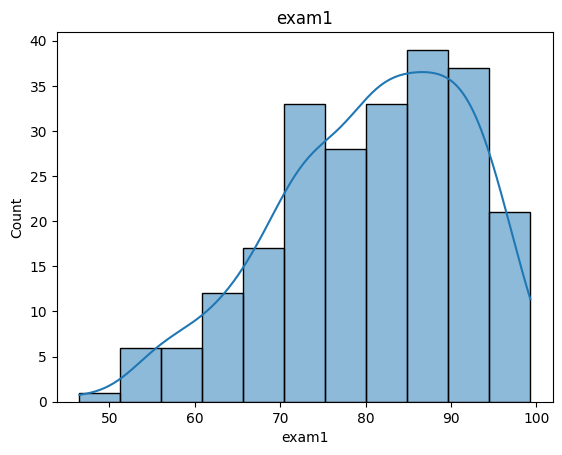

-0.43537280598016087
-0.40309109551464983


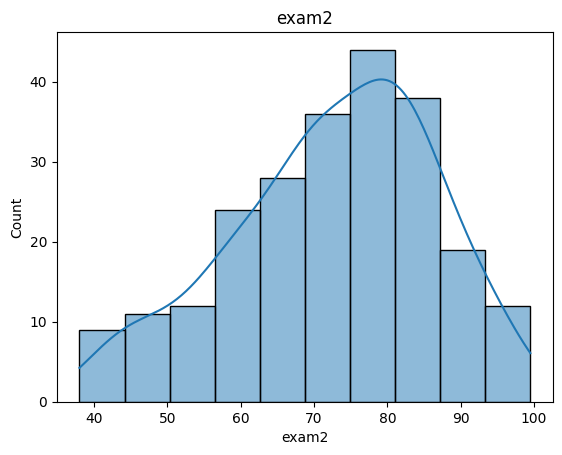

-0.7263758395357777
0.16914666607104545


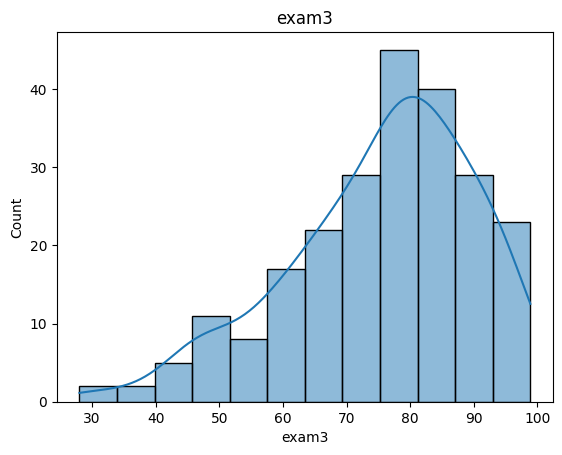

-0.23243097221026465
-0.005210817444612381


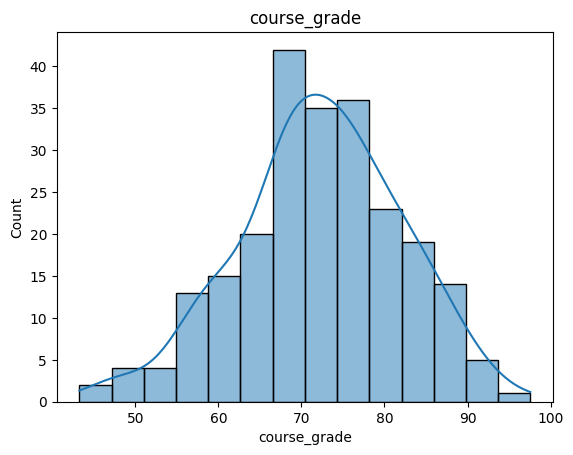

In [101]:
numeric=data.select_dtypes(include=['number'])

for i in numeric:
  print(data[i].skew())
  print(data[i].kurtosis())
  sns.histplot(data[i],kde=True)
  plt.title(i)
  plt.show()

ovdje vidimo histograme za ispite sa jasno oznacenom krivuljom, po grafu mozemo zakljuciti da su sve normalne i iznad svakoga je izracunat skew koji nam govori da li je nagnut na neku stranu i kurtis koji govori hoce li biti šiljast tj visinu.

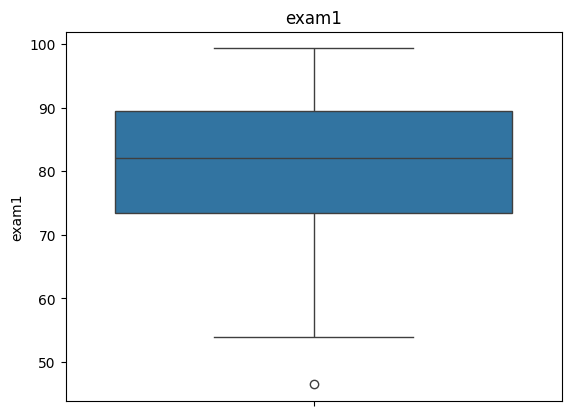

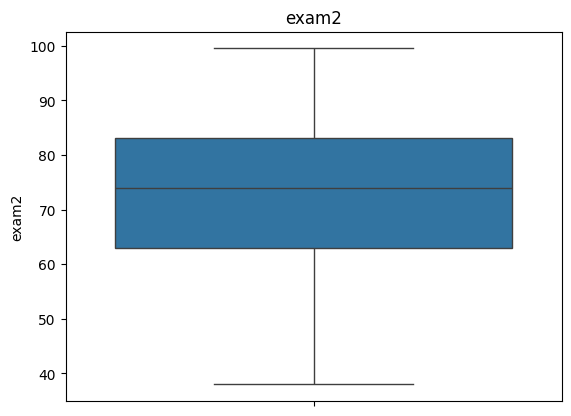

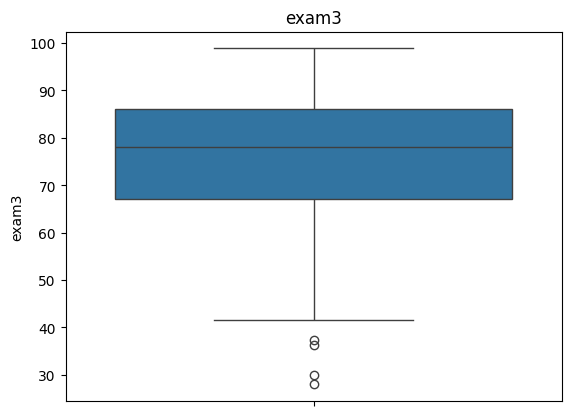

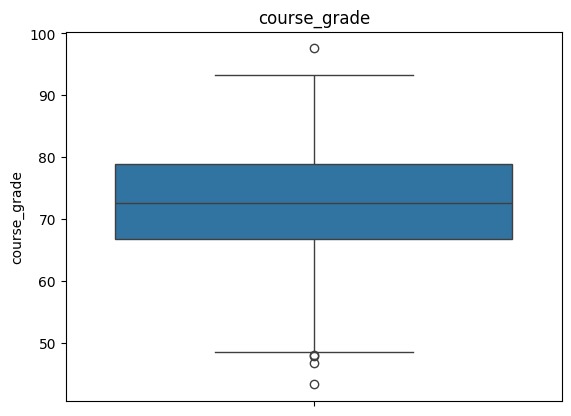

In [38]:
for i in numeric:
    sns.boxplot(data[i])
    plt.title(i)
    plt.show()

ovdje vidimo boxplotove za sve i vidimo da ima outlejera i mozemo iscitati medijan, min max itd

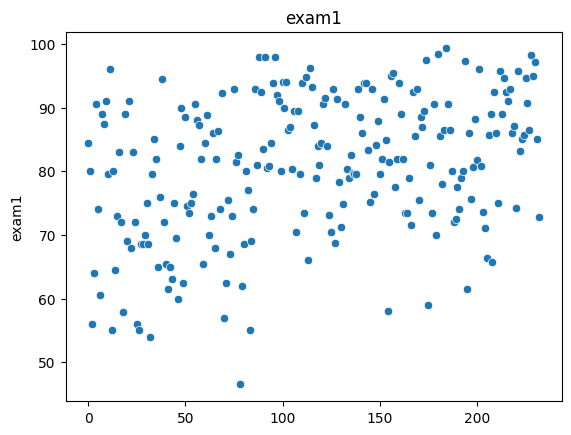

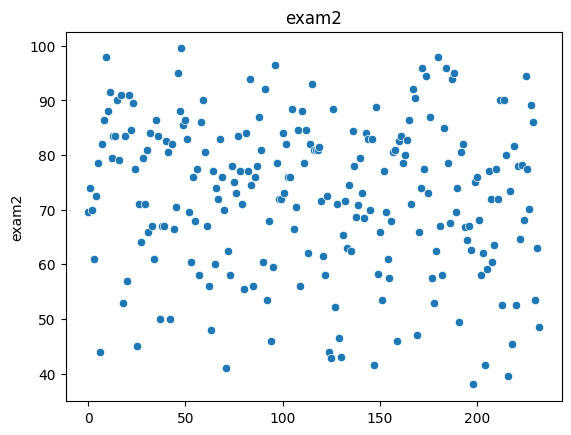

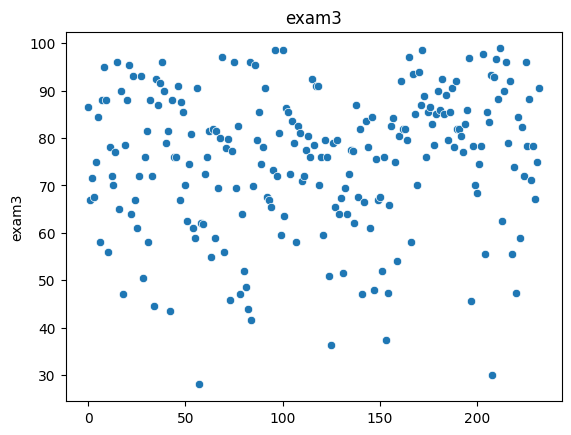

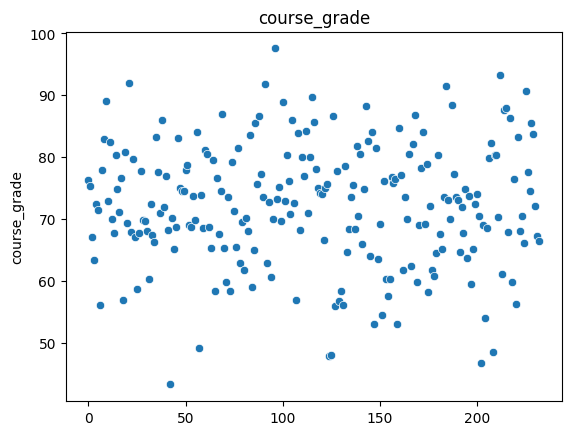

In [39]:
for i in numeric:
    sns.scatterplot(data[i])
    plt.title(i)
    plt.show()

ovdje vidimo scaterplotove tj vidimo rasprsenja

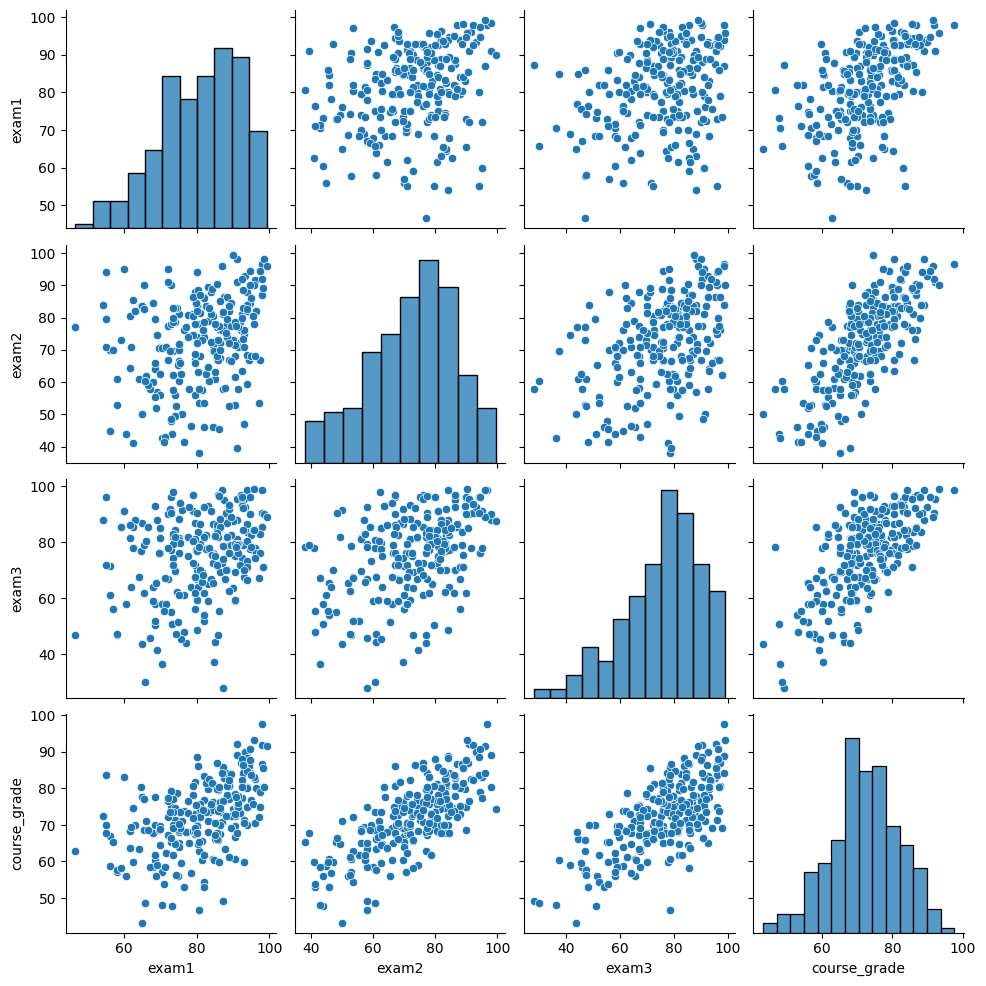

In [36]:
sns.pairplot(data)

ovdje vidimo svaki vs svaki a na glavnoj dijagonali vidimo zapravo varijable.

In [41]:
granice=[0,50,75,100]
l=["loš","srednje","dobar"]
data["ocjena"]=pd.cut(data["course_grade"],bins=granice,labels=l)
data.head()

,semester,sex,exam1,exam2,exam3,course_grade,ocjena
0,2000-1,Man,84.5,69.5,86.5,76.2564,dobar
1,2000-1,Man,80.0,74.0,67.0,75.3882,dobar
2,2000-1,Man,56.0,70.0,71.5,67.0564,srednje
3,2000-1,Man,64.0,61.0,67.5,63.4538,srednje
4,2000-1,Man,90.5,72.5,75.0,72.3949,srednje


u ovome djelu koda smo numericku vrijednost pretvorili u kategoričku ocjena.

In [107]:
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from scipy.stats import pearsonr


In [48]:
grupeS=[]
sex=["Man","Woman"]
for i in sex:
  grupa=data[data['sex']==i].dropna()
  grupeS.append(grupa)
print(grupeS)


[    semester  sex    exam1  exam2    exam3  course_grade   ocjena
0     2000-1  Man  84.5000   69.5  86.5000       76.2564    dobar
1     2000-1  Man  80.0000   74.0  67.0000       75.3882    dobar
2     2000-1  Man  56.0000   70.0  71.5000       67.0564  srednje
3     2000-1  Man  64.0000   61.0  67.5000       63.4538  srednje
4     2000-1  Man  90.5000   72.5  75.0000       72.3949  srednje
..       ...  ...      ...    ...      ...           ...      ...
227   2003-1  Man  86.4286   70.1  88.3333       74.5553  srednje
228   2003-1  Man  98.2143   89.1  71.1111       85.5208    dobar
230   2003-1  Man  97.1429   53.5  67.2222       72.1189  srednje
231   2003-1  Man  85.0000   63.0  75.0000       67.1996  srednje
232   2003-1  Man  72.8571   48.5  90.5556       66.4035  srednje

[188 rows x 7 columns],     semester    sex    exam1  exam2    exam3  course_grade   ocjena
8     2000-1  Woman  87.5000   86.5  95.0000       82.9026    dobar
14    2000-1  Woman  64.5000   83.5  77.0000  

In [49]:
print(data['sex'].value_counts())

sex
Man      188
Woman     45
Name: count, dtype: int64


vidimo da imamo 188 muških i 45 ženskih i gore smo ih razdvojili

In [53]:
for i in grupeS:
  stat,p=shapiro(i['course_grade'])
  print(f"stat={stat},p={p}")

stat=0.9914562799990272,p=0.3324508722002315
stat=0.9722468594952354,p=0.34841611729013716


oba dva su veća od 0.05 što znači da su distribucije normalne i ne odbacujemo nulte hipoteze H0,

In [55]:
for i in grupeS:
  stat,p=levene(i['exam1'],i['exam2'],i['exam3'])
  print(f"stat={stat},p={p}")

stat=6.164657530794306,p=0.002247599688082495
stat=0.8239828749982234,p=0.4409244451708122


vidimo da je kod muskaraca manje od 0.05 ali posto imamo veliki broj studenata i sex ima dvije grupe koristiti ce mo t test

In [58]:
stat,p_val=ttest_ind(grupeS[0]['course_grade'],grupeS[1]['course_grade'])
print(f"stat={stat},p={p_val}")

stat=-1.4868875299377333,p=0.13840815693875033


dobili smo p da je veci od 0.05 što znaci da nema značajnog utjecaja spola na ocijenu, necemo odbiti nultu hipotezu

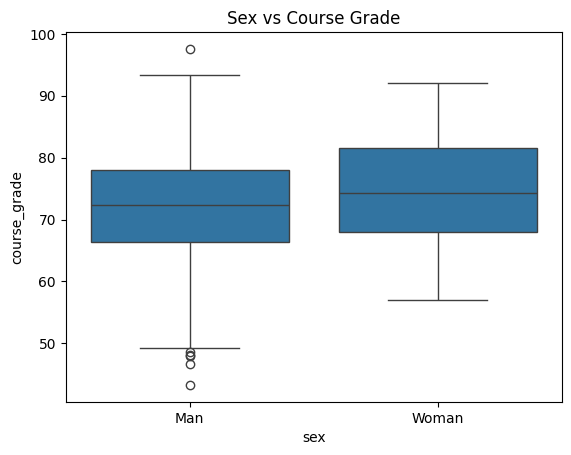

In [61]:
plt.figure()
sns.boxplot(x="sex",y="course_grade",data=data)
plt.title("Sex vs Course Grade")
plt.show()

vidimo da su vrijednosti približno jednake što smo zakljucili i sa t testom da nema znacajne razlike u spolu, kod muškaraca ima outlejera

In [63]:
print(data['semester'].value_counts())

semester
2000-1    51
2001-1    38
2001-2    37
2002-1    36
2003-1    36
2000-2    35
Name: count, dtype: int64


In [64]:
semestar=data['semester'].unique()
print(semestar)

['2000-1' '2000-2' '2001-1' '2001-2' '2002-1' '2003-1']


vidimo da semestar ima 6 razlicitih vrijednosti pa će mo ih grupirati.

In [72]:
grupesem=[]
for i in semestar:
  grupa=data[data['semester']==i]['course_grade'].dropna()
  grupesem.append(grupa)
print(grupesem)

[0     76.2564
1     75.3882
2     67.0564
3     63.4538
4     72.3949
5     71.4128
6     56.0949
7     78.0103
8     82.9026
9     89.0846
10    72.9769
11    82.5282
12    69.9872
13    67.7256
14    80.3051
15    74.8744
16    71.1615
17    76.5615
18    56.9903
19    80.8026
20    69.4308
21    92.0051
22    67.9051
23    79.7872
24    67.1256
25    58.6308
26    67.8308
27    77.6903
28    69.9308
29    69.6769
30    68.0923
31    60.3128
32    72.3821
33    67.4787
34    66.2364
35    83.3231
36    77.6436
37    70.9462
38    86.0133
39    72.0269
40    77.0282
41    68.2821
42    43.2733
43    70.1031
44    65.0846
45    68.6538
46    83.0508
47    75.0856
48    74.4718
49    74.4821
50    77.9526
Name: course_grade, dtype: float64, 51    78.7554
52    69.0228
53    68.6502
54    73.6702
55    69.7842
56    84.1474
57    49.1931
58    73.9116
59    68.5425
60    81.2088
61    80.5554
62    68.7839
63    65.3088
64    79.6035
65    58.4316
66    76.6842
67    67.5625
68    74.57

ovdje smo razdvojili u 6 grupa po semestru sa bodovima

In [70]:
for i in grupesem:
  stat,p=shapiro(i)
  print(f"stat={stat},p={p}")

stat=0.9684331999191546,p=0.19025403945890157
stat=0.9801267158301099,p=0.7632857113259606
stat=0.981514303206585,p=0.7706077165295606
stat=0.9547598676373171,p=0.1373691109170695
stat=0.9739096558845649,p=0.5415037394561757
stat=0.9791235160177146,p=0.7157974087975477


vidimo da su sve grupe normalno distribuirane to nam govori da ne odbacujemo nultu hipotezu i dobra je podloga za  anovu, da je jedan pao nebi mogli raditi anovu

In [73]:
stat,p=levene(grupesem[0],grupesem[1],grupesem[2],grupesem[3],grupesem[4],grupesem[5])
print(f"stat={stat},p={p}")

stat=2.8513882119001335,p=0.016140028086327616


p nam je manji od 0.05 ali pošto je veliki broj studenata možemo raditi oneway anovu

In [74]:
stat,p=f_oneway(*grupesem)
print(f"stat={stat},p={p}")

stat=2.7186413625084485,p=0.020821327882814916


p vrjednost je manje od 0.05 sto znaci da semestar ma statičko značenje za bodove.

In [75]:
pairwise_tukeyhsd=pairwise_tukeyhsd(endog=data['course_grade'],groups=data['semester'])
print(pairwise_tukeyhsd)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
2000-1 2000-2  -1.7389 0.9631  -7.8145  4.3368  False
2000-1 2001-1   4.4174 0.2704  -1.5143 10.3491  False
2000-1 2001-2   -3.347 0.5932  -9.3245  2.6305  False
2000-1 2002-1  -0.0352    1.0  -6.0606  5.9902  False
2000-1 2003-1   0.0302    1.0  -5.9952  6.0556  False
2000-2 2001-1   6.1563 0.0736  -0.3285 12.6411  False
2000-2 2001-2  -1.6081 0.9808  -8.1348  4.9186  False
2000-2 2002-1   1.7037  0.976  -4.8669  8.2743  False
2000-2 2003-1   1.7691 0.9717  -4.8015  8.3397  False
2001-1 2001-2  -7.7644 0.0075 -14.1574 -1.3715   True
2001-1 2002-1  -4.4526 0.3525 -10.8904  1.9851  False
2001-1 2003-1  -4.3872 0.3695  -10.825  2.0505  False
2001-2 2002-1   3.3118 0.6844  -3.1681  9.7918  False
2001-2 2003-1   3.3772 0.6659  -3.1027  9.8571  False
2002-1 2003-1   0.0654    1.0  -6.4588  6.5896  False
----------------------------

ovdje vidimo svaki semestar vs svakog i vidimo da su 2001-1 i 2001-2 jedini koji imaju p_adj manji od 0.05 što znači da su međusobno povezani i jedino kod toga odbacujemo nultu hipotezu, isto tako tu možemo isčitati interval povjerenja sa 95% pouzdanosti to su stupci lower i upper tj to su donja i gornja granica intervala povjerenja

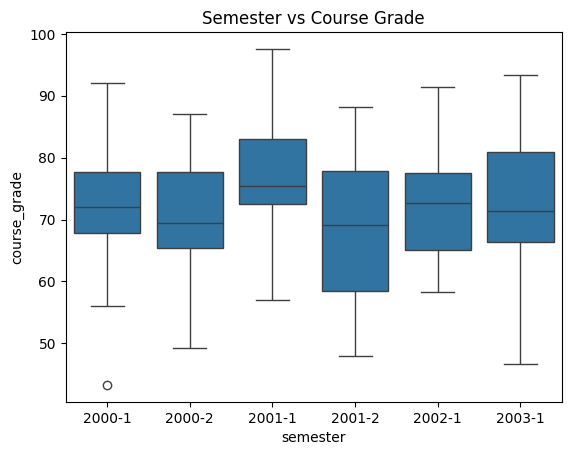

In [76]:
plt.figure()
sns.boxplot(x="semester",y="course_grade",data=data)
plt.title("Semester vs Course Grade")
plt.show()

ovdje možemo vidjeti kako koji semestar utječe na course grade.

In [77]:
data1=pd.crosstab(data['sex'],data['ocjena'])
print(data1)
chi2_stat, p_val, dof, expected = chi2_contingency(data1)
print(chi2_stat)
print(p_val)

ocjena  loš  srednje  dobar
sex                        
Man       6      112     70
Woman     0       25     20
2.024614664879716
0.3633795740709178


p nam je veci od 0.05 sto nam govori kako nema statističke razlike u spolu i ocjenama tj spol ne utjece na ocjene

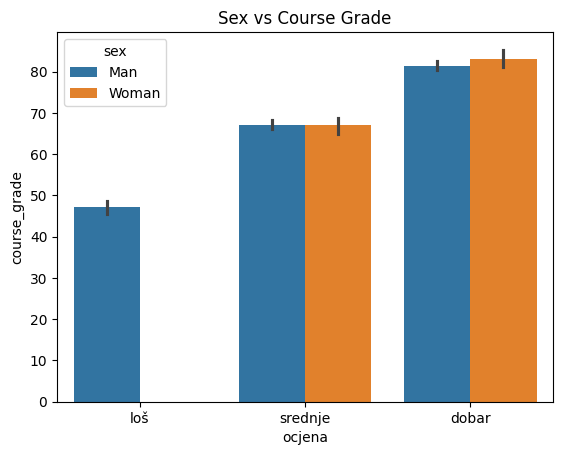

In [80]:
plt.figure()
sns.barplot(x="ocjena",y="course_grade",hue="sex",data=data)
plt.title("Sex vs Course Grade")
plt.show()

In [82]:
from matplotlib import colormaps


       exam1  exam2    exam3  course_grade
0    84.5000   69.5  86.5000       76.2564
1    80.0000   74.0  67.0000       75.3882
2    56.0000   70.0  71.5000       67.0564
3    64.0000   61.0  67.5000       63.4538
4    90.5000   72.5  75.0000       72.3949
..       ...    ...      ...           ...
228  98.2143   89.1  71.1111       85.5208
229  95.0000   86.0  78.3333       83.6959
230  97.1429   53.5  67.2222       72.1189
231  85.0000   63.0  75.0000       67.1996
232  72.8571   48.5  90.5556       66.4035

[233 rows x 4 columns]


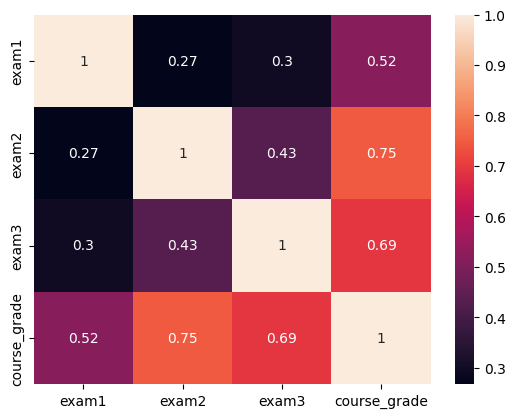

In [83]:
num_data=data.select_dtypes(include=['number'])
print(num_data)
corr=num_data.corr(method='pearson')
sns.heatmap(corr,annot=True)
plt.show()

ovdje vidimo korelacijsku tablicu, najveću povezanost ima exam 2 sa course_grade 0.75, exam 3 isto ima jaku povezanost sa istim 0.69, a najmanju povezanost ima exam1 sa exam2 i exam 1 sa exam 3

In [84]:
from scipy.stats import linregress

slope=0.4603203904899393,intercept=35.06050892497371,r_value=0.5183789438058377,p_value=2.00435379340324e-17,std_err=0.0499631360086142


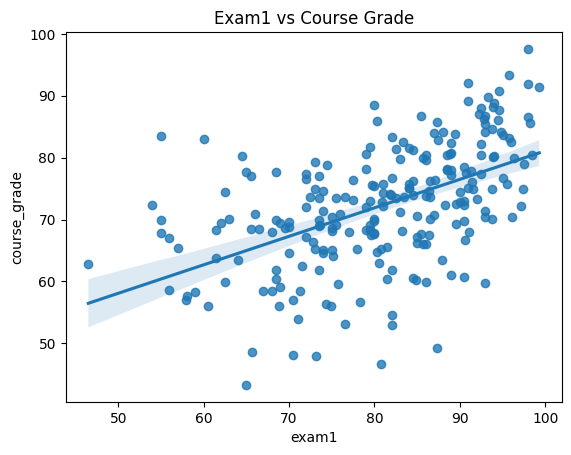

<function matplotlib.pyplot.show(close=None, block=None)>

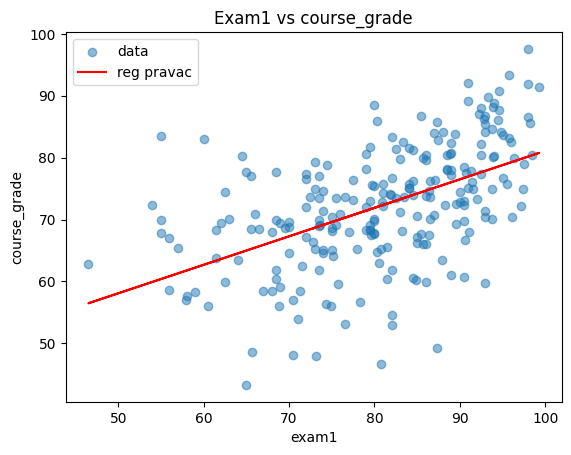

In [92]:
x=data['exam1']
y=data['course_grade']
slope,intercept,r_value,p_value,std_err=linregress(x,y)
print(f"slope={slope},intercept={intercept},r_value={r_value},p_value={p_value},std_err={std_err}")

plt.figure()
sns.regplot(x=x,y=y)
plt.title("Exam1 vs Course Grade")
plt.show()

plt.scatter(x,y,alpha=0.5,label="data")
plt.plot(x,intercept+slope*x,color="red",label="reg pravac")
plt.xlabel('exam1')
plt.ylabel('course_grade')
plt.title( "Exam1 vs course_grade")
plt.legend()
plt.show

iz ovoga vidimo da nam je slope=0.4603203904899393 što znači da ako nam se na exam 1 podigne za bod, course_grade će nam se povećati za vrijednost slopa tj 0.46

In [104]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [103]:
y = data['course_grade']

In [106]:
x=data.copy()
x=x.drop('course_grade',axis=1)
x=x.drop('sex',axis=1)
x=x.drop('ocjena',axis=1)
x=x.drop('semester',axis=1)

X_const=sm.add_constant(x)
model = sm.OLS(y, X_const).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           course_grade   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     284.6
Date:                Mon, 19 Jan 2026   Prob (F-statistic):           5.96e-77
Time:                        14:56:19   Log-Likelihood:                -681.08
No. Observations:                 233   AIC:                             1370.
Df Residuals:                     229   BIC:                             1384.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.1503      2.495      2.866      0.0

za svaku varijablu nam je p manji od 0.05 što znači da dobro opisuje tu varijablu, r kvadrat je 0.789 što znači da 78% opisuje varijancu. i vidimo da najbolje opisuje exame 2 zato sto je t za njega 14.817 tj najveći je

ZAKLJUČAK:
Zaključio sam da spol nema utjecaj na ocjenu,